In [2]:
import numpy as np # to handle matrix and data operation
import pandas as pd # to read csv and handle dataframe

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from torch.autograd import Variable

from sklearn.model_selection import train_test_split

import mnist_cnn_classifier as classify


In [ ]:
path_home = '/home/pathorad3090/Documents/Hadar/SyntheticEvaluation'

path_train_classifier = path_home + '/cnn_classifier/data/train'
path_val_classifier =  path_home + '/cnn_classifier/data/val'

train_loader, validation_loader = classify.create_dataloaders(path_train_classifier, path_val_classifier, batch_size=100, val_subset_size=10000)
train_loader = train_loader
test_loader = validation_loader

100

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=5)
        self.fc2 = nn.Linear(256, 10)  # Output layer remains the same

        # Initializing fc1 with a placeholder value; we'll update it later
        self.fc1 = nn.Linear(1024, 256)  # Placeholder (we'll update this later)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = F.dropout(x, p=0.5, training=self.training)

        # Automatically compute the size of the flattened layer
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch size
        x = F.relu(self.fc1(x))   # Pass through fc1
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)           # Pass through fc2
        return F.log_softmax(x, dim=1)

    def get_flattened_size(self, input_tensor):
        """ Helper function to get the size of the flattened layer """
        x = self.conv1(input_tensor)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv3(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        return x.view(x.size(0), -1).shape[1]

# Initialize the model
cnn = CNN()

# Example usage with new image size: 32x32 instead of 28x28
dummy_input = torch.randn(1, 1, 32, 32)  # A batch of 1 grayscale 32x32 image

# Get the flattened size (can be used for further debugging if needed)
flattened_size = cnn.get_flattened_size(dummy_input)
print(f"Flattened size: {flattened_size}")

# Now update fc1 based on the correct flattened size
cnn.fc1 = nn.Linear(flattened_size, 256)  # Update fc1's input size dynamically

# Test the forward pass with a dummy batch
it = iter(train_loader)
X_batch, y_batch = next(it)
print(cnn.forward(X_batch).shape)


Flattened size: 1024
torch.Size([100, 10])


In [21]:
# Number of batches in the train_loader
num_batches = len(train_loader)
print(f"Number of batches in the train_loader: {num_batches}")

# Get the first batch
X_batch, y_batch = next(iter(train_loader))

# Print the size of the input batch (X_batch) and label batch (y_batch)
print(f"Input batch size: {X_batch.shape}")
print(f"Label batch size: {y_batch.shape}")



Number of batches in the train_loader: 480
Input batch size: torch.Size([100, 1, 32, 32])
Label batch size: torch.Size([100])


In [26]:
def fit(model, train_loader):
    optimizer = torch.optim.Adam(model.parameters())  # Optimizer
    error = nn.CrossEntropyLoss()  # Loss function
    EPOCHS = 5  # Number of epochs
    model.train()  # Set the model to training mode
    
    for epoch in range(EPOCHS):
        correct = 0
        total = 0
        
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            var_X_batch = Variable(X_batch).float()
            var_y_batch = Variable(y_batch)
            
            optimizer.zero_grad()  # Zero the gradients
            output = model(var_X_batch)  # Forward pass
            loss = error(output, var_y_batch)  # Calculate loss
            loss.backward()  # Backpropagate gradients
            optimizer.step()  # Update the weights

            # Total correct predictions
            predicted = torch.max(output.data, 1)[1]
            correct += (predicted == var_y_batch).sum().item()
            total += var_y_batch.size(0)  # Total number of samples

            # Print every 50 batches
            if batch_idx % 50 == 0:
                accuracy = (correct / total) * 100
                print(f"Epoch: {epoch} [{batch_idx * len(X_batch)}/{len(train_loader.dataset)} "
                      f"({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}\t"
                      f"Accuracy: {accuracy:.3f}%")


In [77]:
import torch
from torch.autograd import Variable
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.nn as nn

def fit(model, train_loader, val_loader):
    optimizer = torch.optim.Adam(model.parameters())  # Optimizer
    error = nn.CrossEntropyLoss()  # Loss function
    EPOCHS = 1  # Number of epochs
    model.train()  # Set the model to training mode
    
    # Lists to store loss and accuracy for each batch and each epoch
    train_loss_history = []
    train_accuracy_history = []
    val_loss_history = []
    val_accuracy_history = []

    # Start training log
    print("Starting training...")

    for epoch in range(EPOCHS):
        correct = 0
        total = 0
        train_loss = 0  # Initialize training loss
        epoch_train_loss = []  # Stores the loss for each batch in the epoch
        epoch_train_accuracy = []  # Stores the accuracy for each batch in the epoch

        # Training phase
        num_batches = len(train_loader)
        
        # Calculate the indices to log every 10% of the batches
        log_steps = [int(num_batches * (i / 10)) for i in range(1, 11)]  # 10% intervals
        
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            var_X_batch = Variable(X_batch).float()
            var_y_batch = Variable(y_batch)
            
            optimizer.zero_grad()  # Zero the gradients
            output = model(var_X_batch)  # Forward pass
            loss = error(output, var_y_batch)  # Calculate loss
            loss.backward()  # Backpropagate gradients
            optimizer.step()  # Update the weights

            # Track total correct predictions and loss for the batch
            predicted = torch.max(output.data, 1)[1]
            correct += (predicted == var_y_batch).sum().item()
            total += var_y_batch.size(0)  # Total number of samples
            train_loss += loss.item()  # Add the loss of this batch



            
            # Log results at 10% intervals of the epoch
            if batch_idx in log_steps:
                # Validation phase
                model.eval()  # Set model to evaluation mode
                correct_val = 0
                total_val = 0
                val_loss = 0  # Initialize validation loss 
                 
                train_accuracy = (correct / total) * 100
                epoch_train_loss.append(loss.item())
                epoch_train_accuracy.append(train_accuracy)

                # Append batch loss and accuracy to the history
                train_loss_history.append(loss.item())
                train_accuracy_history.append(train_accuracy)

                print(f"Epoch {epoch+1}/{EPOCHS} - Batch {batch_idx}/{num_batches}: "
                      f"Train Loss: {loss.item():.6f}, Train Accuracy: {train_accuracy:.3f}%")
                
                with torch.no_grad():  # Disable gradient computation for validation
                    for X_batch, y_batch in val_loader:
                        var_X_batch = Variable(X_batch).float()
                        var_y_batch = Variable(y_batch)
                        
                        output = model(var_X_batch)  # Forward pass
                        loss = error(output, var_y_batch)  # Calculate loss
                        predicted = torch.max(output.data, 1)[1]
                        
                        # Track correct predictions and loss for the batch
                        correct_val += (predicted == var_y_batch).sum().item()
                        total_val += var_y_batch.size(0)
                        val_loss += loss.item()  # Add the loss of this batch

                # Calculate validation accuracy and loss
                val_accuracy = (correct_val / total_val) * 100
                avg_val_loss = val_loss / len(val_loader)
                val_loss_history.append(avg_val_loss)
                val_accuracy_history.append(val_accuracy)
                print(f"Epoch {epoch+1}/{EPOCHS}: "
              f"Validation Loss: {avg_val_loss:.6f}, Validation Accuracy: {val_accuracy:.3f}%\n")
                
            model.train()  # Set the model back to training mode
        
        # Log validation results at the end of each epoch

    return train_loss_history, train_accuracy_history, val_loss_history, val_accuracy_history

# This function will plot the results after training
def plot_graphs(train_loss, train_acc, val_loss, val_acc):
    # Plot loss
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Validation Loss")
    plt.title("Loss")
    plt.xlabel("Batch (per epoch)")
    plt.ylabel("Loss")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label="Train Accuracy")
    plt.plot(val_acc, label="Validation Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Batch (per epoch)")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    plt.show()


In [78]:
cnn = CNN()
dummy_input = torch.randn(1, 1, 32, 32)  # A batch of 1 grayscale 32x32 image
flattened_size = cnn.get_flattened_size(dummy_input)
cnn.fc1 = nn.Linear(flattened_size, 256)  # Update fc1's input size dynamically


train_loss, train_acc, val_loss, val_acc = fit(cnn, train_loader, test_loader)


Starting training...
Epoch 1/1 - Batch 48/480: Train Loss: 0.610735, Train Accuracy: 55.551%
Epoch 1/1: Validation Loss: 0.364555, Validation Accuracy: 89.630%

Epoch 1/1 - Batch 96/480: Train Loss: 0.285923, Train Accuracy: 71.165%
Epoch 1/1: Validation Loss: 0.235294, Validation Accuracy: 92.650%

Epoch 1/1 - Batch 144/480: Train Loss: 0.211354, Train Accuracy: 77.766%
Epoch 1/1: Validation Loss: 0.161917, Validation Accuracy: 94.830%

Epoch 1/1 - Batch 192/480: Train Loss: 0.234341, Train Accuracy: 81.352%
Epoch 1/1: Validation Loss: 0.128749, Validation Accuracy: 95.970%

Epoch 1/1 - Batch 240/480: Train Loss: 0.231001, Train Accuracy: 83.660%
Epoch 1/1: Validation Loss: 0.111068, Validation Accuracy: 96.630%

Epoch 1/1 - Batch 288/480: Train Loss: 0.161136, Train Accuracy: 85.367%
Epoch 1/1: Validation Loss: 0.105922, Validation Accuracy: 96.890%

Epoch 1/1 - Batch 336/480: Train Loss: 0.154195, Train Accuracy: 86.774%
Epoch 1/1: Validation Loss: 0.086454, Validation Accuracy: 97.

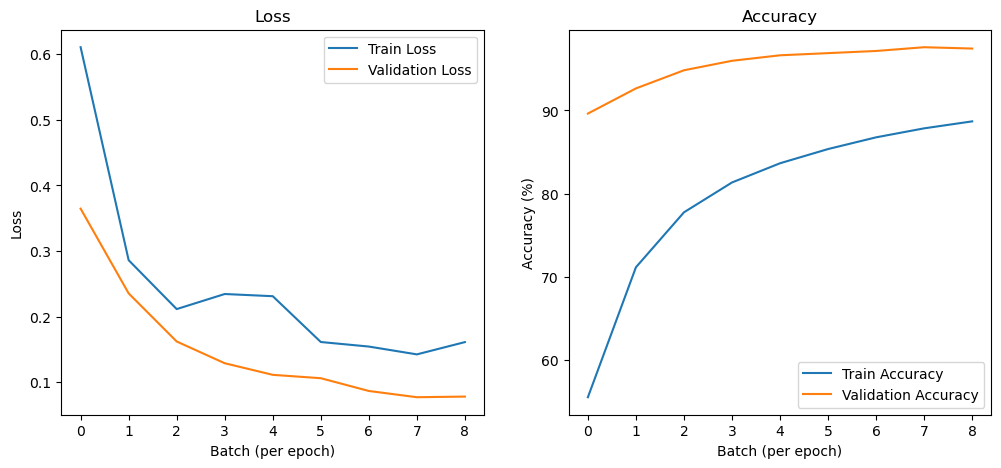

In [79]:
plot_graphs(train_loss, train_acc, val_loss, val_acc)
